In [ ]:
import pandas as pd
import numpy as np
import gc
import torch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import os
os.chdir("/Users/zengjian/PyTorch/MLP/data/")
# ==========================================
# 步骤 1：处理 Y 标签，圈定目标样本
# ==========================================
print("1. 正在处理 Y 标签数据...")
y_file = "merged_sample_quality_annotations.tsv" 

df_y = pd.read_csv(y_file, sep="\t", usecols=['aliquot_barcode', 'cancer type'])
df_y = df_y.drop_duplicates(subset=['aliquot_barcode'], keep='first')
df_y.set_index('aliquot_barcode', inplace=True)

class_counts = df_y['cancer type'].value_counts()
valid_classes = class_counts[class_counts >= 20].index
df_y_filtered = df_y[df_y['cancer type'].isin(valid_classes)]

valid_y_samples = set(df_y_filtered.index)
print(f"   - 过滤 <20 样本的类别后，剩余类别数: {len(valid_classes)}")

# ==========================================
# 步骤 2：获取 X 表头，制定极速读取计划
# ==========================================
print("\n2. 正在生成 X 数据的读取计划...")
x_file = "expression.tsv" 

x_header_df = pd.read_csv(x_file, sep="\t", nrows=0)
x_all_cols = x_header_df.columns.tolist()

gene_col_name = x_all_cols[0] 
x_sample_cols = set(x_all_cols[1:])

target_samples = list(x_sample_cols.intersection(valid_y_samples))
cols_to_read = [gene_col_name] + target_samples 

# ==========================================
# 步骤 3：分块读取 X 并清洗 (去NA、方差过滤、转置)
# ==========================================
print("\n3. 开始分块读取与清洗 X 数据...")
chunk_size = 2000  
chunks_list = []
# 你可以根据需要调整这个阈值，这里假设 > 10000 会剩下约 1.4W 个特征
variance_threshold = 10

reader = pd.read_csv(x_file, sep="\t", index_col=0, usecols=cols_to_read, chunksize=chunk_size)

for i, chunk in enumerate(reader):
    chunk = chunk.dropna(axis=0, how='any')
    if not chunk.empty:
        var = chunk.var(axis=1)
        chunk = chunk[var > variance_threshold]
    if not chunk.empty:
        chunks_list.append(chunk.T)
        
    if (i + 1) % 5 == 0:
        print(f"   - 已扫描 { (i + 1) * chunk_size } 行原始基因...")

del reader
gc.collect()

# ==========================================
# 步骤 4：拼接 X 与对齐 Y 标签
# ==========================================
print("\n4. 正在拼接特征矩阵并对齐标签...")
X_final = pd.concat(chunks_list, axis=1)
del chunks_list
gc.collect()

X_final = X_final[~X_final.index.duplicated(keep='first')]
y_final = df_y_filtered.loc[X_final.index]

# 将文字标签 (如 'BRCA', 'LUAD') 转换为数字索引 (0, 1, 2...)
le = LabelEncoder()
y_encoded = le.fit_transform(y_final['cancer type'])

print(f"   - 拼接完成！特征矩阵形状: {X_final.shape}")

# ==========================================
# 步骤 5：标准化 (StandardScaler) —— 极其重要
# ==========================================
print("\n5. 开始 Z-score 标准化...")
scaler = StandardScaler()
# 保持 1.4W 维特征不变，仅将数值缩放到均值0，方差1
X_scaled = scaler.fit_transform(X_final)

# 清理内存
# del X_final
# gc.collect()

# ==========================================
# 步骤 6：划分数据集并转换为 PyTorch DataLoader
# ==========================================
print("\n6. 正在构建 PyTorch 数据管道...")

# 划分 80% 训练集，20% 验证集 (使用 stratify 保证各类别比例一致)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_encoded  # <--- 这里的参数是灵魂
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp     # <--- 注意这里用的是 y_temp
)
# 转换为 PyTorch Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
# 构建 Dataset 和 DataLoader
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid_tensor, y_valid_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
print("\n" + "="*40)
print("✅ 数据预处理全部通关！")
print(f"   最终保留的特征维度: {X_train_tensor.shape[1]} 维")
print(f"   训练集样本数: {X_train_tensor.shape[0]}, 验证集样本数: {X_valid_tensor.shape[0]}")
print(f"   分类目标类别数: {len(le.classes_)}")
print("="*40)

1. 正在处理 Y 标签数据...
   - 过滤 <20 样本的类别后，剩余类别数: 33

2. 正在生成 X 数据的读取计划...

3. 开始分块读取与清洗 X 数据...
   - 已扫描 10000 行原始基因...
   - 已扫描 20000 行原始基因...

4. 正在拼接特征矩阵并对齐标签...
   - 拼接完成！特征矩阵形状: (11069, 16278)

5. 开始 Z-score 标准化...

6. 正在构建 PyTorch 数据管道...

✅ 数据预处理全部通关！
   最终保留的特征维度: 16278 维
   训练集样本数: 7748, 验证集样本数: 1660
   分类目标类别数: 33


In [20]:
print(X_scaled[:5])

[[-0.65457059 -0.66248833 -0.09339982 ... -0.89838803 -0.20014026
  -0.49312463]
 [-0.70249326 -0.22926845 -0.63140217 ... -0.51115942  0.94627964
   0.12717222]
 [-0.78048441 -0.43745184 -0.58863379 ... -0.63961828  0.30427208
  -0.97226265]
 [-0.92230961 -0.86720171 -0.84615315 ... -0.73100522 -0.22706005
  -0.74441463]
 [-0.92230961 -0.61687271 -0.74342904 ... -1.25829046 -0.76084353
  -0.85664288]]


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. 定义 MLP 模型架构
# ==========================================
class TCGA_CancerMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        # 输入层到隐藏层 1 (大漏斗结构)
        # 你的 input_dim 约为 1.4W，这一层负责降维和特征提取
        self.fc1 = nn.Linear(input_dim, 1024)
        self.bn1 = nn.BatchNorm1d(1024) # 批归一化，加速收敛
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.5)    # 强力 Dropout 防止过拟合
        
        # 隐藏层 1 到隐藏层 2
        self.fc2 = nn.Linear(1024, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        
        # 输出层 (映射到癌症类别数)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))
        x = self.fc3(x) # 注意：CrossEntropyLoss 自带 Softmax，这里不需要加
        return x

# ==========================================
# 2. 初始化模型、损失函数与优化器
# ==========================================
# 假设 X_train_tensor.shape[1] 就是你的输入维度 (约 1.4W)
input_dim = X_train_tensor.shape[1]
# 假设 le.classes_ 是你之前 LabelEncoder 得到的类别列表
num_classes = len(le.classes_) 

# 将模型移至 GPU (如果有)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TCGA_CancerMLP(input_dim, num_classes).to(device)

# 【核心设计 1：计算类别权重，对抗样本不均匀】
# y_train 是之前划分出来的训练集标签 (numpy 数组格式)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 定义加权交叉熵损失
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# 定义优化器 (Adam 优化器在组学数据上表现非常稳健)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # weight_decay 即 L2 正则化

# ==========================================
# 3. 训练循环 (含 L1 正则化与验证评估)
# ==========================================
num_epochs = 20
l1_lambda = 1e-4  # L1 惩罚系数，需要根据实际 Loss 规模微调
best_val_acc = 0.0

print(f"🚀 开始在 {device} 上训练模型...\n")

for epoch in range(num_epochs):
    # --- 训练阶段 ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # 梯度清零
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(batch_x)
        
        # 【核心设计 2：构建总损失 = 加权分类损失 + L1 正则化】
        classification_loss = criterion(outputs, batch_y)
        
        # 只对第一层的权重 (fc1) 施加 L1 惩罚，迫使无用的基因权重变为 0
        l1_penalty = torch.norm(model.fc1.weight, p=1)
        
        # 总损失计算
        loss = classification_loss + l1_lambda * l1_penalty
        
        # 反向传播与权重更新
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # 统计训练准确率
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    train_acc = 100 * correct_train / total_train
    
    # --- 验证阶段 ---
    model.eval()  # 关闭 Dropout 和 BatchNorm 的动态更新
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # 验证阶段不计算梯度，节省显存
        for batch_x, batch_y in valid_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
    val_acc = 100 * correct_val / total_val
    
    # 打印每个 Epoch 的日志
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(valid_loader):.4f}, Val Acc: {val_acc:.2f}%")
    
    # --- 模型保存逻辑 ---
    # 如果当前验证集准确率是历史上最好的，就保存模型权重
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_tcga_mlp.pth')

print(f"\n🎉 训练完成！最高验证集准确率: {best_val_acc:.2f}%")
print("已将最佳模型权重保存为 'best_tcga_mlp.pth'")

🚀 开始在 cpu 上训练模型...

Epoch [1/50] Train Loss: 5.1168, Train Acc: 77.90% | Val Loss: 0.5756, Val Acc: 87.05%
Epoch [2/50] Train Loss: 4.0517, Train Acc: 86.59% | Val Loss: 0.5442, Val Acc: 84.88%
Epoch [3/50] Train Loss: 4.5984, Train Acc: 85.89% | Val Loss: 0.4285, Val Acc: 87.41%
Epoch [4/50] Train Loss: 3.8296, Train Acc: 86.87% | Val Loss: 0.4196, Val Acc: 87.89%
Epoch [5/50] Train Loss: 4.3779, Train Acc: 87.26% | Val Loss: 0.4871, Val Acc: 88.55%
Epoch [6/50] Train Loss: 4.2068, Train Acc: 86.56% | Val Loss: 0.4308, Val Acc: 88.43%
Epoch [7/50] Train Loss: 4.1424, Train Acc: 87.17% | Val Loss: 0.4354, Val Acc: 89.34%
Epoch [8/50] Train Loss: 4.4064, Train Acc: 86.76% | Val Loss: 0.4656, Val Acc: 83.80%
Epoch [9/50] Train Loss: 4.5479, Train Acc: 86.67% | Val Loss: 0.3590, Val Acc: 89.94%
Epoch [10/50] Train Loss: 4.1405, Train Acc: 87.48% | Val Loss: 0.3793, Val Acc: 87.53%
Epoch [11/50] Train Loss: 5.0072, Train Acc: 86.72% | Val Loss: 0.4062, Val Acc: 88.01%
Epoch [12/50] Train L

正在加载验证集上表现最好的模型权重...


/var/folders/0g/1st6ryj54n1bshvyq3yt1pzm0000gn/T/ipykernel_60354/300619747.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_tcga_m


🔥 激动人心的时刻！测试集最终准确率: 91.27%

------------------------------------------------------------
各癌症类型详细分类报告 (关注小样本的 Recall):
------------------------------------------------------------
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        12
        BLCA       0.83      0.84      0.84        64
        BRCA       1.00      0.96      0.98       183
        CESC       0.90      1.00      0.95        47
        CHOL       0.50      0.83      0.62         6
        COAD       0.74      0.96      0.84        75
        DLBC       0.88      1.00      0.93         7
        ESCA       0.55      0.97      0.70        29
         GBM       0.96      0.85      0.90        26
        HNSC       0.99      1.00      0.99        85
        KICH       0.63      0.92      0.75        13
        KIRC       1.00      0.84      0.91        91
        KIRP       0.81      0.88      0.84        49
        LAML       0.93      1.00      0.96        26
         

/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

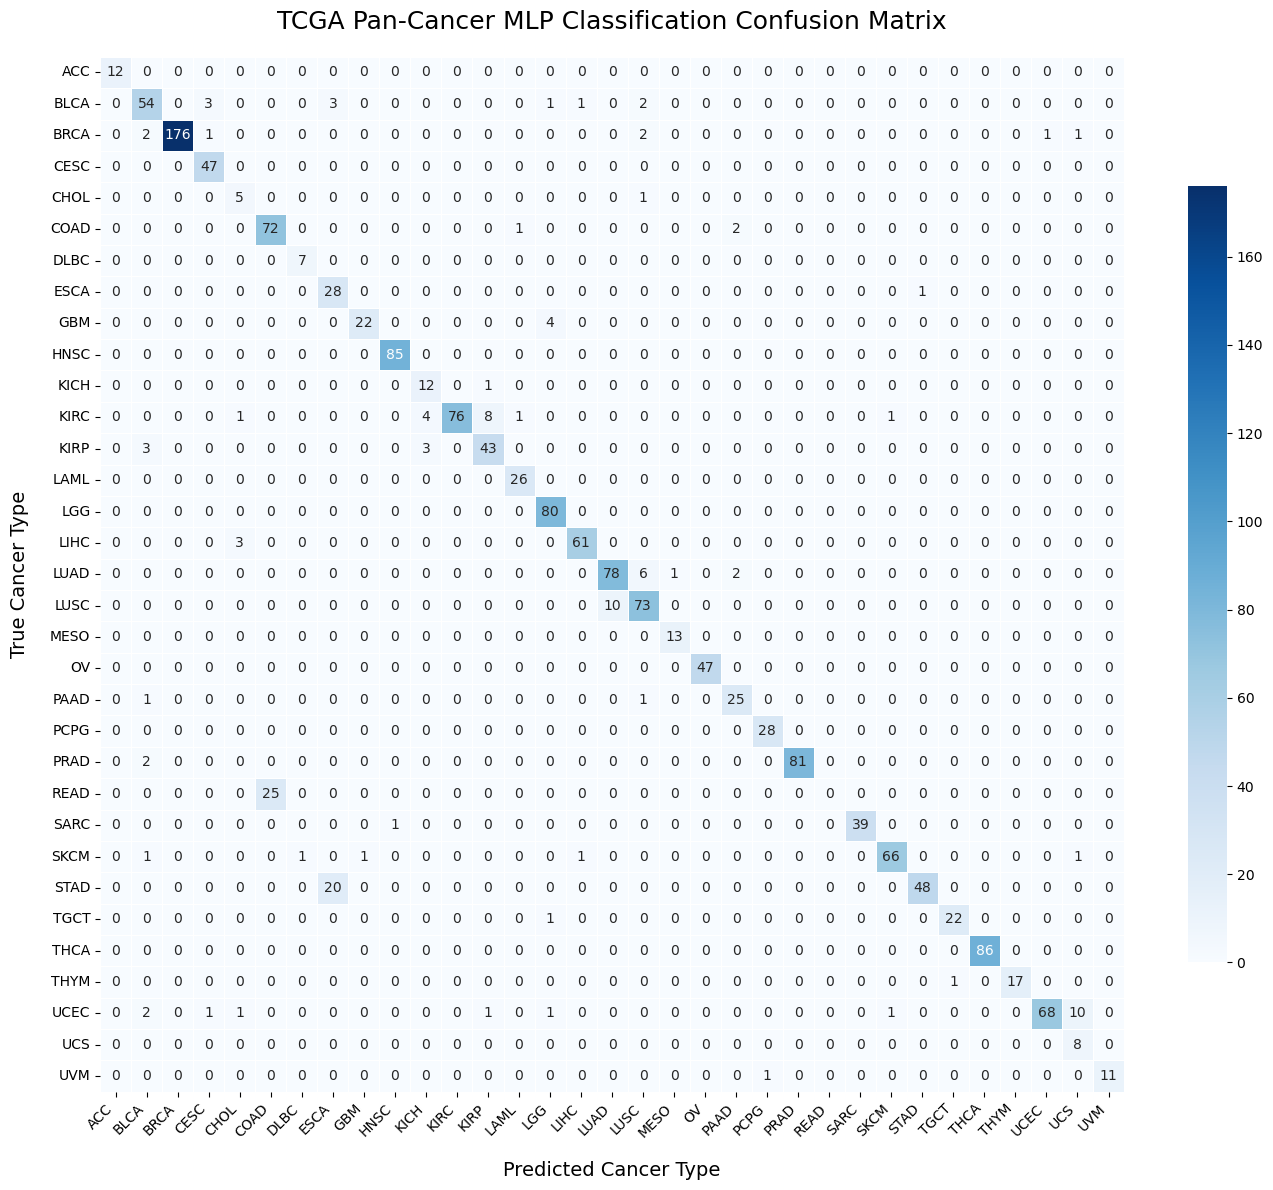

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. 加载最佳模型权重
# ==========================================
print("正在加载验证集上表现最好的模型权重...")
# 确保网络结构已经实例化为 model，且 device 已经定义
model.load_state_dict(torch.load('best_tcga_mlp.pth'))

# 极其重要：切换到评估模式！
# 这会关闭 Dropout，并冻结 BatchNorm 的均值和方差更新
model.eval() 

# ==========================================
# 2. 在 Test DataLoader 上进行推理
# ==========================================
all_preds = []
all_labels = []

# 假设你之前已经构建好了 test_loader
with torch.no_grad(): # 测试阶段不需要计算梯度，极大节省显存并提速
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        
        # 前向传播得到预测 logits
        outputs = model(batch_x)
        
        # 获取概率最大的那个类别的索引
        _, predicted = torch.max(outputs, 1)
        
        # 将预测结果和真实标签转移到 CPU 并转为 numpy 列表存起来
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# ==========================================
# 3. 输出最终评估指标
# ==========================================
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n🔥 激动人心的时刻！测试集最终准确率: {test_acc:.2f}%\n")

# 获取真实的癌症类型名称 (如 BRCA, LUAD)
# 假设 le 是你之前训练时使用的 LabelEncoder 实例
class_names = le.classes_

print("-" * 60)
print("各癌症类型详细分类报告 (关注小样本的 Recall):")
print("-" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 4. 绘制高颜值混淆矩阵 (Confusion Matrix)
# ==========================================
# 计算混淆矩阵的数值
cm = confusion_matrix(all_labels, all_preds)

# 设置画板大小 (TCGA 类别多，画板需要大一点)
plt.figure(figsize=(14, 12))

# 使用 Seaborn 绘制热图
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('TCGA Pan-Cancer MLP Classification Confusion Matrix', fontsize=18, pad=20)
plt.xlabel('Predicted Cancer Type', fontsize=14, labelpad=15)
plt.ylabel('True Cancer Type', fontsize=14, labelpad=15)

# 调整刻度标签的角度，防止重叠
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
# 如果你想保存图片到本地，可以取消下面这行的注释
# plt.savefig('confusion_matrix_tcga.png', dpi=300)
plt.show()

In [15]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        12
        BLCA       0.83      0.84      0.84        64
        BRCA       1.00      0.96      0.98       183
        CESC       0.90      1.00      0.95        47
        CHOL       0.50      0.83      0.62         6
        COAD       0.74      0.96      0.84        75
        DLBC       0.88      1.00      0.93         7
        ESCA       0.55      0.97      0.70        29
         GBM       0.96      0.85      0.90        26
        HNSC       0.99      1.00      0.99        85
        KICH       0.63      0.92      0.75        13
        KIRC       1.00      0.84      0.91        91
        KIRP       0.81      0.88      0.84        49
        LAML       0.93      1.00      0.96        26
         LGG       0.92      1.00      0.96        80
        LIHC       0.97      0.95      0.96        64
        LUAD       0.89      0.90      0.89        87
        LUSC       0.86    

/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [ ]:
# 这 25 个 READ（直肠腺癌） 样本，绝大多数（甚至全部）都被模型预测成了 COAD（结肠腺癌）！
# 它们本来就是同一种病： COAD（结肠癌） 和 READ（直肠癌） 在解剖学上紧挨着，在分子分型、基因组变异和转录组表达谱上几乎是完全一样的。
# 可选：将所有的 READ 替换为 COAD
df_y['cancer type'] = df_y['cancer type'].replace('READ', 'COAD')

#解剖与分子的模糊地带： STAD（胃腺癌）和 ESCA（食管癌） 在解剖学上是紧密相连的。
#尤其是发生于食管下段的腺癌与胃贲门部的腺癌，它们在起源细胞、致癌突变途径以及转录组表达谱上，存在极高的重叠，甚至在分子水平上几乎无法区分。
#TCGA 的官方操作： 正因为它们太像了，TCGA 官方和许多顶尖生信论文经常将 STAD 和 ESCA 合并在一起进行分析，
#并将其统称为 STES（Stomach and Esophageal carcinoma，胃食管癌）。

In [23]:
print(X_final.columns.tolist()[:5])

['?|100133144', '?|100134869', '?|10357', '?|10431', '?|155060']


正在逆向解剖 MLP 第一层权重...

🏆 Top 10 绝对核心标志物 (Biomarkers):
            Gene  Importance
    CDC26|246184   13.331923
LOC407835|407835   11.903965
     KANK1|23189   11.591043
  UBE2MP1|606551   10.755510
  PA2G4P4|647033   10.594642
        LOX|4015   10.462242
      CLK2P|1197   10.131387
  ATP5EP2|432369   10.023292
     CD274|29126    9.758755
   HS3ST3A1|9955    9.617636


/var/folders/0g/1st6ryj54n1bshvyq3yt1pzm0000gn/T/ipykernel_60354/277355742.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


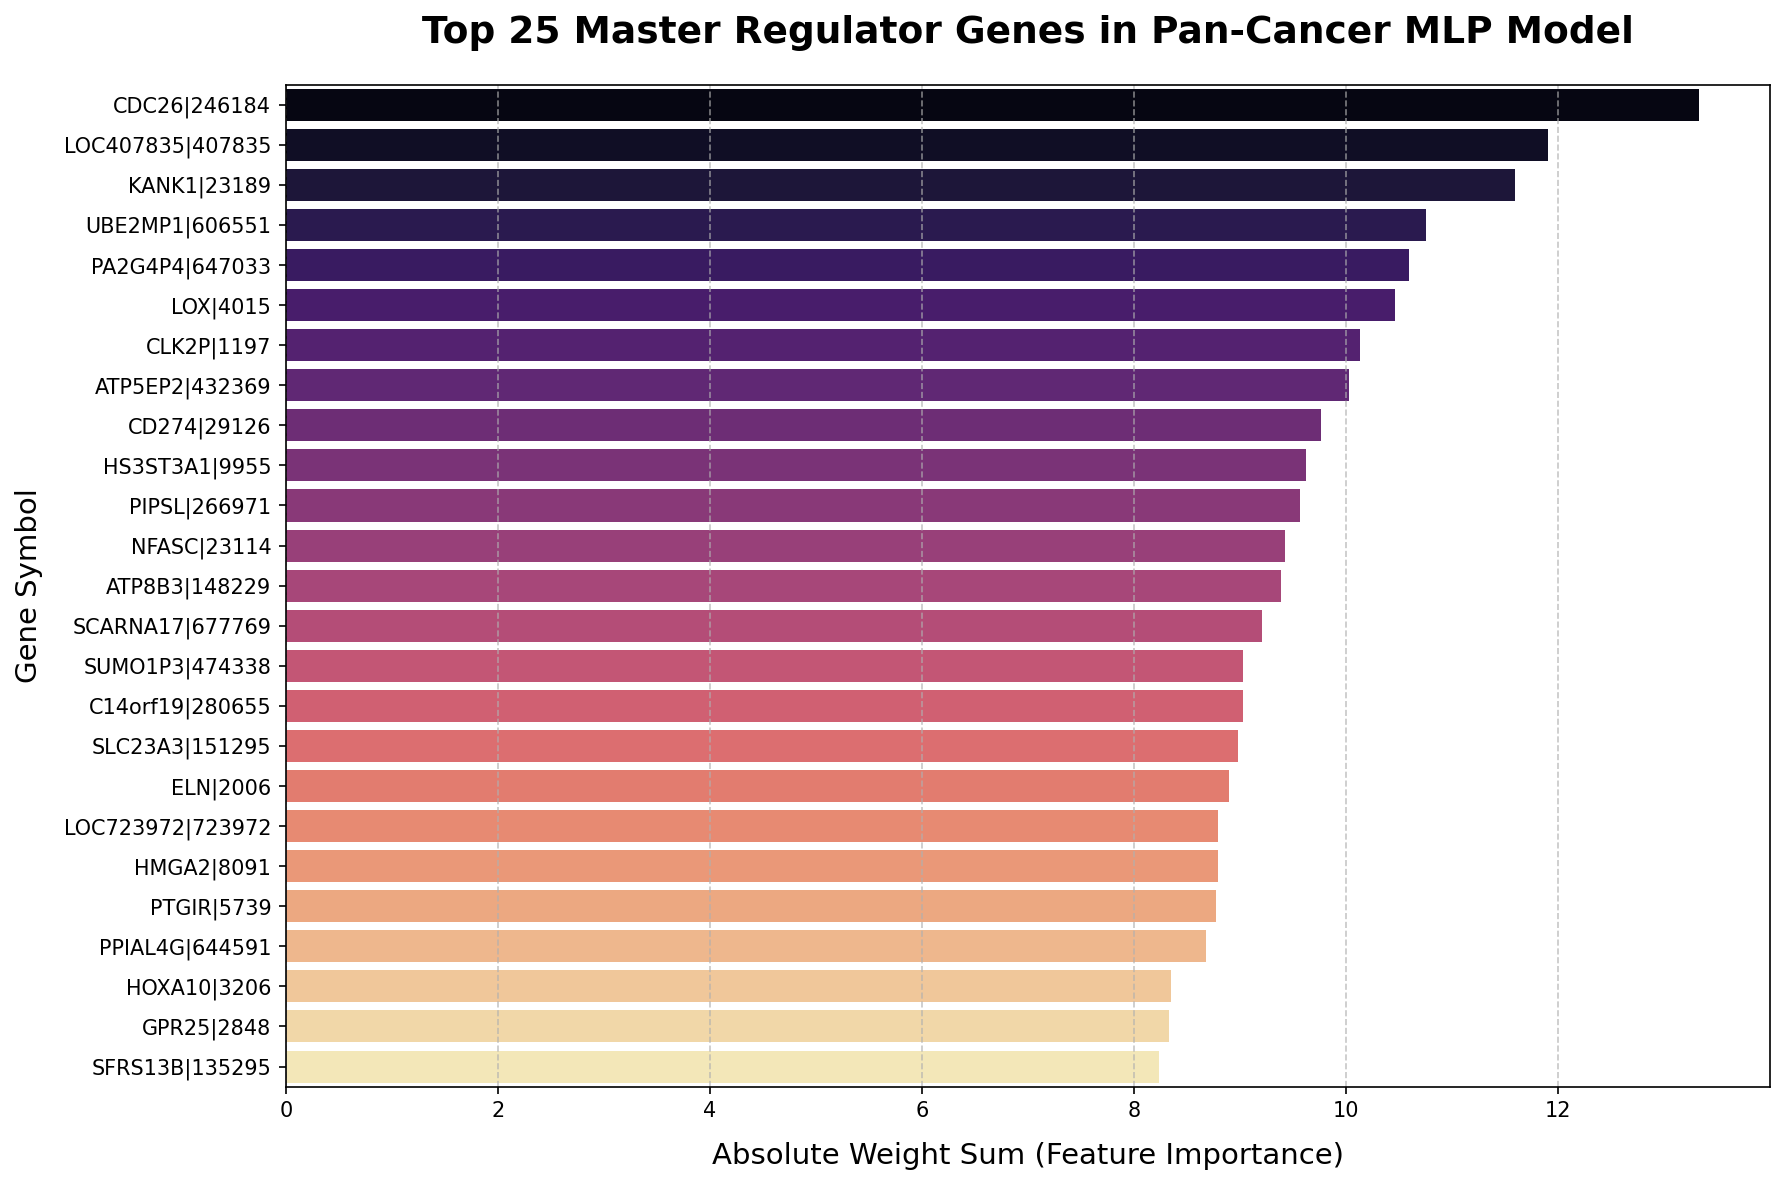

In [24]:
# 提取模型第一层的权重，揪出到底是哪些 Top 50 的关键基因主导了这场高精度的分类大战？
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 提取模型第一层权重
# ==========================================
print("正在逆向解剖 MLP 第一层权重...")
# 确保模型在 CPU 上，方便转为 numpy
model.cpu()

# fc1 的权重形状是 [隐藏层神经元数, 输入特征数] (例如: [1024, 14000])
fc1_weights = model.fc1.weight.data.numpy()

# ==========================================
# 2. 计算基因的“全局重要性得分”
# ==========================================
# 逻辑：对于每一个输入基因，把它连接到下游 1024 个神经元的所有权重取绝对值，然后求和。
# 得分越大，说明这个基因对整个网络的决策影响越深烈。
gene_importance = np.sum(np.abs(fc1_weights), axis=0)

# ==========================================
# 3. 匹配基因名并排序
# ==========================================
# 注意：你需要提取出之前保留下来的那 1.4W 个基因的名称
# 如果你之前没有单独存，可以重新从 cols_to_read 或者你的原始 X 文件表头里提取
# 假设你已经获取了特征名列表 gene_names (长度必须与 gene_importance 一致)
# gene_names = list(X_final.columns) # 如果你的 X_final 还在内存里的话

# 这里为你提供一种安全的获取基因名的方式（基于我们之前的逻辑）：
x_header_df = pd.read_csv("expression.tsv", sep="\t", nrows=0)
all_genes = x_header_df.index.tolist() # 转置前的 index 就是基因名
# 假设你之前用方差过滤保存了一个列表 filtered_genes
gene_names = X_final.columns.tolist() 

# 构建 DataFrame
importance_df = pd.DataFrame({
    'Gene': gene_names,  # 请替换为真实的特征名列表变量
    'Importance': gene_importance
})

# 降序排列，提取 Top 50
top_50_genes = importance_df.sort_values(by='Importance', ascending=False).head(50)

print("\n🏆 Top 10 绝对核心标志物 (Biomarkers):")
print(top_50_genes.head(10).to_string(index=False))

# ==========================================
# 4. 绘制高颜值重要性图谱
# ==========================================
# 设置高分辨率画板
plt.figure(figsize=(12, 8), dpi=150)

# 使用 seaborn 绘制水平条形图，选取 Top 25 以保证排版美观
sns.barplot(
    x='Importance', 
    y='Gene', 
    data=top_50_genes.head(25), 
    palette='magma' # magma 配色非常有科研高级感
)

# 细节润色
plt.title('Top 25 Master Regulator Genes in Pan-Cancer MLP Model', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Absolute Weight Sum (Feature Importance)', fontsize=14, labelpad=10)
plt.ylabel('Gene Symbol', fontsize=14, labelpad=10)

# 添加网格线辅助视觉对齐
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# 保存图片
# plt.savefig('top_genes_importance.png', bbox_inches='tight')
plt.show()